In [1]:
import joblib
import numpy as np
from dataset import *
from rmap import *
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import networkx as nx
from sklearn.metrics import average_precision_score, roc_auc_score

target_cores = [0,1,3,7,8]

## Epsilon sensitivity analysis

In [ ]:
global_dicts = [] # adding 0.001 to adjacency matrix every time
iter_connect_dicts = [] # Iteratively connecting smaller components to larger components if two or more components
only_if_dicts = [] # adding 0.001 to adjacency matrix only if two or more components

for t in target_cores :
    global_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_eps-3.0.joblib"))
    iter_connect_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_eps0.0.joblib"))
    only_if_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib"))

In [31]:
# Sanity check that randomly left out tests and all first selections are the same
for global_dict2, iter_dict2, only_dict2 in zip(global_dicts, iter_connect_dicts, only_if_dicts):
    for gd_test, id_test, od_test in zip(global_dict2["test_bb_inds"], iter_dict2["test_bb_inds"], only_dict2["test_bb_inds"]) :
        assert np.all(gd_test == id_test)
        assert np.all(id_test == od_test)
    for gd_test, id_test, od_test in zip(global_dict2["remaining_inds"], iter_dict2["remaining_inds"], only_dict2["remaining_inds"]) :
            assert np.all(gd_test == id_test)
            assert np.all(id_test == od_test)

In [41]:
# First lest evaluate the impact of adding 0.001 to cases when number of components is 1
for od, gd in zip(only_if_dicts, global_dicts) :
    for o1, g1 in zip(od["proba"], gd["proba"]) :
        print(np.all(o1 == g1))
    print()

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False

False
False
False
False
True
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False



In [26]:
global_dicts[0].keys()

dict_keys(['bootstrap_id', 'selection_id', 'train_bb_inds', 'test_bb_inds', 'proba', 'target', 'Number of desired reactivity class in first batch', 'remaining_inds', 'LP thresholds', 'num components', 'pilot_thresholds', 'Number of pilots'])

In [4]:
eps_zero_dicts = []
eps_001_dicts = []
prev_dicts = []
for t in [0, 1, 3, 7, 8] :
    eps_zero_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap_predefined_eps0.joblib"))
    eps_001_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap_predefined.joblib"))
    prev_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap.joblib"))

In [16]:
a = np.array([3, 7, 1, 60, 21, 3, 7])
np.unique(a)

array([ 1,  3,  7, 21, 60])

In [ ]:

for zero_dict, target_core, prev_dict in zip(eps_zero_dicts, [0,1,3,7,8], prev_dicts):
    print("==================")
    print("TARGET CORE", target_core)
    print("==================")
    for x, test_bb_ind_list in enumerate(zero_dict["test_bb_inds"]) :
        dataset = SuzukiDataset(from_notebook=True)
        rmap = ReactivityMap(
            source_core_inds=None, 
            target_core_ind=target_core, 
            test_bb_inds=test_bb_ind_list, 
            dataset=dataset
        )
        _ = rmap.get_similarity_matrix()
        outer_adj = rmap._similarity_matrix_to_adjacency_matrix(
            rmap.get_similarity_matrix(), 0.82
        )
        G = nx.from_numpy_array(outer_adj)
        if nx.number_connected_components(G) > 1 :
            print(x, [len(y) for y in nx.connected_components(G)], np.sum(rmap.source_reactivity_array[:, list(list(nx.connected_components(G))[1])], axis=0))

TARGET CORE 0
TARGET CORE 1
3 [53, 2] [14 11]
6 [53, 2] [14 11]
12 [53, 2] [14 11]
TARGET CORE 3
3 [53, 2] [14 11]
6 [53, 2] [14 11]
12 [53, 2] [14 11]
TARGET CORE 7
6 [53, 2] [14 11]
TARGET CORE 8
6 [53, 2] [14 11]


In [3]:
# Asserting that the evaluation setting is the same
for zero_dict, dict_001 in zip(eps_zero_dicts, eps_001_dicts):
    for k, v1 in zero_dict.items():
        if k in ["bootstrap_id", "test_bb_inds", "remaining_inds"]:
            v2 = dict_001[k]
            try :
                assert v2 == v1
            except :
                print(k)
                print(v1[0])
                print(v2[0])
                print()

test_bb_inds
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]

test_bb_inds
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]

test_bb_inds
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]

test_bb_inds
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]

test_bb_inds
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]
[ 0  4  5  9 10 12 18 22 31 33 44 47 53 59]



## Impact of CV

### For selecting threshold for LP

[-0.12845832 -0.0264496  -0.01635681 -0.00737674 -0.00568533 -0.00413163
 -0.00281643  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.01260456  0.06240293
  0.0724113   0.07553007]
0.768599616742681 0.7375343077652574

[-0.13372732 -0.11618461 -0.08757736 -0.07053383 -0.06114426 -0.04579816
 -0.03351624 -0.02479885 -0.01534117 -0.01106326 -0.00866217  0.
  0.          0.          0.          0.01579646  0.02213002  0.02262628
  0.04395147  0.08106927]
0.767254116467409 0.7799026389909496

[-0.04474183 -0.03846513 -0.03355818 -0.03250594 -0.03123976 -0.01478711
 -0.00826092  0.          0.          0.          0.          0.
  0.01242894  0.01733991  0.02337265  0.02771759  0.02973396  0.03446133
  0.03639578  0.06946544]
0.8848378010384543 0.8871030341609734

[-0.12810455 -0.12216761 -0.06149293 -0.05879009 -0.03761648 -0.03687871
 -0.03383136 -0.0127367  -0.010044   -0.00809758 -0.00393033  0.
  0.          0.          0.        

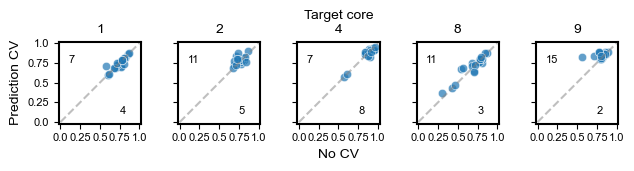

In [75]:
dict_to_plot = {
    "No CV AUPRC":[],
    "No CV ROC-AUC":[], 
    "Prediction CV AUPRC":[],
    "Prediction CV ROC-AUC":[], 
    "Target core":[],
}
for t in target_cores :
    predCV_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap_cv.joblib")
    noCV_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap_predefined.joblib")
    for noCV_proba, predCV_proba, y_target, y_target_pred, noCV_inds, predCV_inds in zip(noCV_results["proba"], predCV_results["proba"], noCV_results["target"], predCV_results["target"], noCV_results["remaining_inds"], predCV_results["remaining_inds"]):
        assert np.all(np.array(noCV_inds) == np.array(predCV_inds))  # Making sure that the pilot BB selection was consistent across the two evaluations
        assert np.all(np.array(y_target) == np.array(y_target_pred))  # Making sure that the pilot BB selection was consistent across the two evaluations
        noCV_score = average_precision_score(y_target, noCV_proba)
        noCV_score2 = roc_auc_score(y_target, noCV_proba)
        predCV_score = average_precision_score(y_target, predCV_proba)
        predCV_score2 = roc_auc_score(y_target, predCV_proba)

        dict_to_plot["No CV AUPRC"].append(noCV_score)
        dict_to_plot["No CV ROC-AUC"].append(noCV_score2)
        dict_to_plot["Prediction CV AUPRC"].append(predCV_score)
        dict_to_plot["Prediction CV ROC-AUC"].append(predCV_score2)
        dict_to_plot["Target core"].append(t)

df_to_plot = pd.DataFrame(dict_to_plot)
fig, ax = plt.subplots(figsize=(6.5, 2), ncols=5, tight_layout=True, sharey=True)
for i, t in enumerate(target_cores):
    sub_df = df_to_plot[df_to_plot["Target core"]==t]
    score_diffs = sub_df["No CV AUPRC"].values - sub_df["Prediction CV AUPRC"].values
    ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
    ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
    print(np.sort(score_diffs))
    print(sub_df["No CV AUPRC"].median(), sub_df["Prediction CV AUPRC"].median())
    print()
    sns.scatterplot(data=sub_df, x="No CV AUPRC", y="Prediction CV AUPRC", ax=ax[i], alpha=0.7)
    ax[i].set_aspect("equal")
    for axis in ["top", "bottom", "left", "right"]:
        ax[i].spines[axis].set_linewidth(1.5)
    ax[i].set_xlim(-0.02, 1.02)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].set_xticks(np.arange(0, 1.1, 0.25))
    ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
    ax[i].set_yticks(np.arange(0, 1.1, 0.25))
    if i == 0 :
        ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_ylabel("Prediction CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    if i == 2 :
        ax[i].set_xlabel("No CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    else :
        ax[i].set_xlabel("")
        ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})


    ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    plt.savefig("../figures/eval_second/FigureS25C_PredCV_vs_noCV_pairwise_comparison.svg", format="svg", dpi=300,  bbox_inches="tight")

### For pilot BB selection

[-0.2125422  -0.08273276 -0.06312088 -0.04413965  0.0040639   0.01598828
  0.05336869]
0.7547926341611463 0.771716120760715

[-0.11622577 -0.03816605 -0.01804954 -0.01173821  0.00528431  0.01363651]
0.7242313578355588 0.7586737425772938

[-0.0265545   0.00060175  0.01149869  0.0165595   0.04281406  0.05646259]
0.8751007489103018 0.8490782087496246

[-0.31846641  0.24247833  0.42124245]
0.6288419617875246 0.4418604651162791

[-0.27030491 -0.10479242 -0.03178823 -0.02894473 -0.02396268 -0.02249505
 -0.00286854 -0.00108857  0.00424174  0.01146804  0.01936716  0.0198139 ]
0.8361464835567749 0.8304889506255532



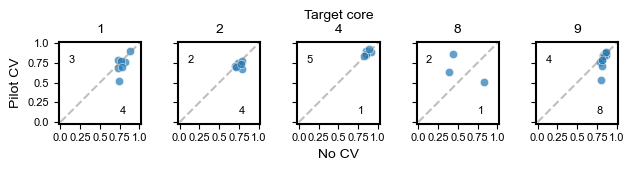

In [74]:
pilot_diff_dict = {
    "Pilot CV AUPRC":[],
    "Pilot CV ROC-AUC":[],
    "Fixed AUPRC":[],
    "Fixed ROC-AUC":[],
    "Target core":[]
}

for t in target_cores :
    predCV_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_6_rmap_cv.joblib")
    bothCV_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")

    for a, (pred_inds, both_inds) in enumerate(zip(predCV_results["remaining_inds"], bothCV_results["remaining_inds"])):
        # print(bothCV_results["LP thresholds"][a])
        pred_selected_inds = [x for x in np.arange(55) if x not in pred_inds]
        both_selected_inds = [x for x in np.arange(55) if x not in both_inds]
        assert len(pred_selected_inds) == 6
        count = 0
        for ind in pred_selected_inds :
            if ind in both_selected_inds :
                count += 1
        # print(count, len(both_inds), len(pred_inds))
        if count == 6 : # Making sure that same pilot BBs lead to same results
            assert np.all(predCV_results["proba"][a] == bothCV_results["proba"][a])
            # print(bothCV_results["LP thresholds"][a], bothCV_results["pilot_thresholds"][a])
        else :
            # Now getting the cross-section of the remaining inds
            cross_remaining_inds = [x for x in pred_inds if x in both_inds]
            y_cross_pred = predCV_results["target"][a][[pred_inds.index(x) for x in cross_remaining_inds]]
            y_cross_both = bothCV_results["target"][a][[both_inds.index(x) for x in cross_remaining_inds]]
            assert np.all(y_cross_pred == y_cross_both)
            cross_pred_proba = predCV_results["proba"][a][[pred_inds.index(x) for x in cross_remaining_inds]]
            cross_both_proba = bothCV_results["proba"][a][[both_inds.index(x) for x in cross_remaining_inds]]
            
            pilot_diff_dict["Pilot CV AUPRC"].append(average_precision_score(y_cross_both, cross_both_proba))
            pilot_diff_dict["Pilot CV ROC-AUC"].append(roc_auc_score(y_cross_both, cross_both_proba))
            pilot_diff_dict["Fixed AUPRC"].append(average_precision_score(y_cross_pred, cross_pred_proba))
            pilot_diff_dict["Fixed ROC-AUC"].append(roc_auc_score(y_cross_pred, cross_pred_proba))
            pilot_diff_dict["Target core"].append(t)

            # print(t, a, bothCV_results["LP thresholds"][a], bothCV_results["pilot_thresholds"][a])
        
        # Interestingly the LP thresholds are always lower than the pilot thresholds, 
        assert bothCV_results["LP thresholds"][a] <= bothCV_results["pilot_thresholds"][a]


df_to_plot = pd.DataFrame(pilot_diff_dict)
fig, ax = plt.subplots(figsize=(6.5, 2), ncols=5, tight_layout=True, sharey=True)
for i, t in enumerate(target_cores):
    sub_df = df_to_plot[df_to_plot["Target core"]==t]
    score_diffs = sub_df["Pilot CV AUPRC"].values - sub_df["Fixed AUPRC"].values
    ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
    ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
    print(np.sort(score_diffs))
    print(sub_df["Pilot CV AUPRC"].median(), sub_df["Fixed AUPRC"].median())
    print()
    sns.scatterplot(data=sub_df, x="Fixed AUPRC", y="Pilot CV AUPRC", ax=ax[i], alpha=0.7)
    ax[i].set_aspect("equal")
    for axis in ["top", "bottom", "left", "right"]:
        ax[i].spines[axis].set_linewidth(1.5)
    ax[i].set_xlim(-0.02, 1.02)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].set_xticks(np.arange(0, 1.1, 0.25))
    ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
    ax[i].set_yticks(np.arange(0, 1.1, 0.25))
    if i == 0 :
        ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_ylabel("Pilot CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    if i == 2 :
        ax[i].set_xlabel("No CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    else :
        ax[i].set_xlabel("")
        ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})


    ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    plt.savefig("../figures/eval_second/FigureS25D_PilotCV_vs_FixedCV_pairwise_comparison.svg", format="svg", dpi=300,  bbox_inches="tight")

## Impact of global epsilon

In [ ]:
# First making sure that all the pilot BB selections are the same across the two evaluations (with and without epsilon=0.001)
for t in target_cores :
    eps3_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_eps-3.0.joblib")
    eps0_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")
    for eps3_inds, eps0_inds in zip(eps3_results["remaining_inds"], eps0_results["remaining_inds"]):
        assert np.all(np.array(eps3_inds) == np.array(eps0_inds))  # Making sure that the pilot BB selection was consistent across the two evaluations
        

[-2.87807431e-03 -1.36752137e-03 -1.19617225e-03 -8.33333333e-04
 -6.41025641e-04 -3.79956301e-04 -2.22044605e-16 -1.11022302e-16
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.22044605e-16  2.23598211e-03  4.81565246e-03  1.26224921e-01]
0.7255824104325672 0.7259990770992338

[-5.29100529e-03 -3.13904361e-03 -1.13636364e-03 -4.98270445e-04
 -1.11022302e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  2.22044605e-16  1.32703405e-04  3.11832801e-04
  4.62962963e-04  7.24637681e-04  1.13095238e-03  3.14300143e-03
  5.00000000e-03  5.59523810e-03  8.77192982e-03  1.76358656e-02]
0.7756482770120056 0.7699612236970954

[-9.33282921e-02 -2.52189828e-03 -1.58864448e-03 -1.04555333e-03
 -1.11022302e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  3.78931413e-04  7.14285714e-04  7.38916256e-04  9.26955877e-04
  9.534403

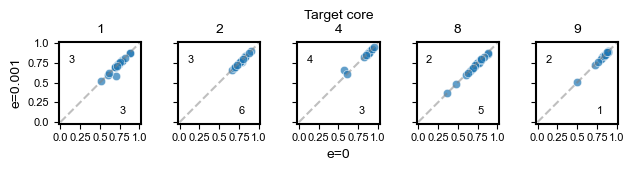

In [ ]:
dict_to_plot = {
    "No e AUPRC":[],
    "No e ROC-AUC":[], 
    "e=0.001 AUPRC":[],
    "e=0.001 ROC-AUC":[], 
    "Target core":[],
}


for t in target_cores :
    eps3_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_eps-3.0.joblib")
    eps0_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")
    for eps3_proba, eps0_proba, y_target, y_target_0, eps3_inds, eps0_inds in zip(eps3_results["proba"], eps0_results["proba"], eps3_results["target"], eps0_results["target"], eps3_results["remaining_inds"], eps0_results["remaining_inds"]):
            assert np.all(np.array(y_target) == np.array(y_target_0))  # Making sure that the pilot BB selection was consistent across the two evaluations
            eps3_score = average_precision_score(y_target, eps3_proba)
            eps3_score2 = roc_auc_score(y_target, eps3_proba)
            eps0_score = average_precision_score(y_target, eps0_proba)
            eps0_score2 = roc_auc_score(y_target, eps0_proba)

            dict_to_plot["No e AUPRC"].append(eps0_score)
            dict_to_plot["No e ROC-AUC"].append(eps0_score2)
            dict_to_plot["e=0.001 AUPRC"].append(eps3_score)
            dict_to_plot["e=0.001 ROC-AUC"].append(eps3_score2)
            dict_to_plot["Target core"].append(t)
    
df_to_plot = pd.DataFrame(dict_to_plot)
fig, ax = plt.subplots(figsize=(6.5, 2), ncols=5, tight_layout=True, sharey=True)
for i, t in enumerate(target_cores):
    sub_df = df_to_plot[df_to_plot["Target core"]==t]
    score_diffs = sub_df["No e AUPRC"].values - sub_df["e=0.001 AUPRC"].values
    ax[i].annotate(len(np.where(score_diffs < -0.001)[0]), (0.1, 0.75), font="arial", fontsize=8)
    ax[i].annotate(len(np.where(score_diffs > 0.001)[0]), (0.75, 0.1), font="arial", fontsize=8)
    print(np.sort(score_diffs))
    print(sub_df["No e AUPRC"].median(), sub_df["e=0.001 AUPRC"].median())
    print()
    sns.scatterplot(data=sub_df, x="No e AUPRC", y="e=0.001 AUPRC", ax=ax[i], alpha=0.7)
    ax[i].set_aspect("equal")
    for axis in ["top", "bottom", "left", "right"]:
        ax[i].spines[axis].set_linewidth(1.5)
    ax[i].set_xlim(-0.02, 1.02)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].set_xticks(np.arange(0, 1.1, 0.25))
    ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
    ax[i].set_yticks(np.arange(0, 1.1, 0.25))
    if i == 0 :
        ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_ylabel("e=0.001", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    if i == 2 :
        ax[i].set_xlabel("e=0", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    else :
        ax[i].set_xlabel("")
        ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})


    ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    plt.savefig("../figures/eval_second/FigureS42_impact_of_global_epsilon.svg", format="svg", dpi=300,  bbox_inches="tight")

# Selecting the *number* of pilot BBs with CV

In [80]:
npilot_diff_dict = {
    "N-Pilot CV AUPRC":[],
    "N-Pilot CV ROC-AUC":[],
    "Fixed AUPRC":[],
    "Fixed ROC-AUC":[],
    "Target core":[]
}

selected_n = {t:[] for t in target_cores}
for t in target_cores :
    fixedN_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")
    CV_N_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_-1_rmap_cv.joblib")
    
    for a, (fixedN_inds, CV_N_inds) in enumerate(zip(fixedN_results["remaining_inds"], CV_N_results["remaining_inds"])):
        selected_n[t].append(55 - len(CV_N_inds))

        cross_remaining_inds = [x for x in fixedN_inds if x in CV_N_inds]
        y_cross_fixed = fixedN_results["target"][a][[fixedN_inds.index(x) for x in cross_remaining_inds]]
        y_cross_CV = CV_N_results["target"][a][[CV_N_inds.index(x) for x in cross_remaining_inds]]
        assert np.all(y_cross_fixed == y_cross_CV)
        cross_fixed_proba = fixedN_results["proba"][a][[fixedN_inds.index(x) for x in cross_remaining_inds]]
        cross_CV_proba = CV_N_results["proba"][a][[CV_N_inds.index(x) for x in cross_remaining_inds]]

        npilot_diff_dict["N-Pilot CV AUPRC"].append(average_precision_score(y_cross_CV, cross_CV_proba))
        npilot_diff_dict["N-Pilot CV ROC-AUC"].append(roc_auc_score(y_cross_CV, cross_CV_proba))
        npilot_diff_dict["Fixed AUPRC"].append(average_precision_score(y_cross_fixed, cross_fixed_proba))
        npilot_diff_dict["Fixed ROC-AUC"].append(roc_auc_score(y_cross_fixed, cross_fixed_proba))
        npilot_diff_dict["Target core"].append(t)
        

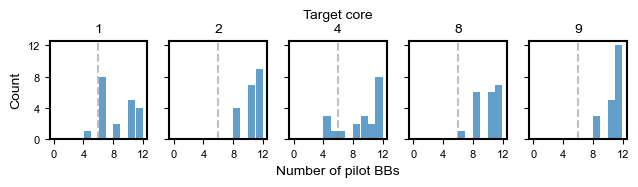

In [81]:
fig, ax = plt.subplots(figsize=(6.5, 2), ncols=5, tight_layout=True, sharey=True)
for i, t in enumerate(target_cores):
    ax[i].hist(selected_n[t], bins=np.arange(0, 13, 1), alpha=0.7, rwidth=0.95)
    for axis in ["top", "bottom", "left", "right"]:
        ax[i].spines[axis].set_linewidth(1.5)
    ax[i].set_xticks(np.arange(0, 13, 4))    
    ax[i].set_xticklabels(np.arange(0, 13, 4), fontsize=8,fontfamily="Arial")
    if i == 0 :
        ax[i].set_ylabel("Count", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_yticks(np.arange(0, 13, 4))
        ax[i].set_yticklabels(np.arange(0, 13, 4), fontsize=8,fontfamily="Arial")
    if i == 2 :
        ax[i].set_xlabel("Number of pilot BBs", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    else :
        ax[i].set_xlabel("")
        ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    ax[i].axvline(6, ls="--", color="grey", alpha=0.5)
plt.savefig("../figures/eval_second/FigureS31_nPilotCV.svg", format="svg", dpi=300,  bbox_inches="tight")

[-0.05709818 -0.05101574 -0.03920642 -0.01781321 -0.01196671 -0.0110101
 -0.0047847  -0.00274455  0.          0.          0.          0.
  0.          0.          0.          0.          0.0030927   0.01932562
  0.09638739  0.22459293]
0.745 0.728

[-0.12456913 -0.06802347 -0.02341602 -0.01360714 -0.0075458  -0.00337277
 -0.00151667  0.00186853  0.00768464  0.01737985  0.02328509  0.02494408
  0.02649242  0.03057866  0.04589992  0.0463996   0.07839642  0.09095669
  0.09455115  0.13968751]
0.785 0.763

[-0.1318109  -0.06710975 -0.05504239 -0.05195168 -0.03136512 -0.01446597
 -0.01260931 -0.01188244 -0.00294055 -0.00160921  0.          0.00290022
  0.00886713  0.01447488  0.01455184  0.02534435  0.0340643   0.04474249
  0.21192275  0.21926568]
0.863 0.887

[-0.41072196 -0.2667695  -0.24470829 -0.24360927 -0.18042368 -0.12597503
 -0.12350813 -0.11996385 -0.05266729 -0.03057675 -0.02867576 -0.02625053
 -0.01222922 -0.00773887  0.          0.02022966  0.05277976  0.05400706
  0.31384222  0.

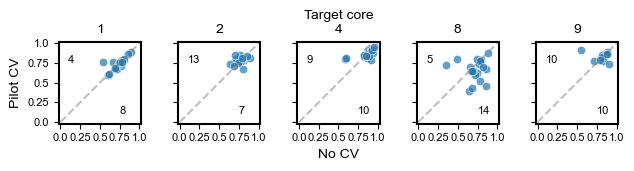

In [82]:
df_to_plot = pd.DataFrame(npilot_diff_dict)
fig, ax = plt.subplots(figsize=(6.5, 2), ncols=5, tight_layout=True, sharey=True)
for i, t in enumerate(target_cores):
    sub_df = df_to_plot[df_to_plot["Target core"]==t]
    score_diffs = sub_df["N-Pilot CV AUPRC"].values - sub_df["Fixed AUPRC"].values
    ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
    ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
    print(np.sort(score_diffs))
    print(round(sub_df["N-Pilot CV AUPRC"].median(), 3),   round(sub_df["Fixed AUPRC"].median(), 3))
    print()
    sns.scatterplot(data=sub_df, x="Fixed AUPRC", y="N-Pilot CV AUPRC", ax=ax[i], alpha=0.7)
    ax[i].set_aspect("equal")
    for axis in ["top", "bottom", "left", "right"]:
        ax[i].spines[axis].set_linewidth(1.5)
    ax[i].set_xlim(-0.02, 1.02)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].set_xticks(np.arange(0, 1.1, 0.25))
    ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
    ax[i].set_yticks(np.arange(0, 1.1, 0.25))
    if i == 0 :
        ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_ylabel("Pilot CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    if i == 2 :
        ax[i].set_xlabel("No CV", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
    else :
        ax[i].set_xlabel("")
        ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})


    ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    plt.savefig("../figures/eval_second/FigureS32_PilotCV_vs_Fixed_pairwise_comparison.svg", format="svg", dpi=300,  bbox_inches="tight")

# LP vs Baseline vs RFC

In [2]:
## Checking that RFC's array transformations are accurate
for t in target_cores :
    rfc_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rfc_combined.joblib")
    baseline_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline.joblib")
    lp_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")

    for a, (rfc_inds, baseline_inds, lp_inds) in enumerate(zip(rfc_results["remaining_inds"], baseline_results["remaining_inds"], lp_results["remaining_inds"])):
        assert np.all(np.array(rfc_inds) == np.array(baseline_inds))  # Making sure that the pilot BB selection was consistent across the two evaluations
        assert np.all(np.array(rfc_inds) == np.array(lp_inds))  # Making sure that the pilot BB selection was consistent across the two evaluations

    for a, (rfc_target, baseline_target, lp_target) in enumerate(zip(rfc_results["target"], baseline_results["target"], lp_results["target"])):
        assert np.all(np.array(rfc_target) == np.array(baseline_target))  # Making sure that the pilot BB selection was consistent across the two evaluations
        assert np.all(np.array(rfc_target) == np.array(lp_target))  # Making sure that the pilot BB selection was consistent across the two evaluations
        

In [ ]:
## Checking that RFC's array transformations are accurate

score_dict_to_plot = {
    "AUPRC":[],
    "ROC-AUC":[],
    "Model":[],
    "Target core":[]
}
topk_hit_dict_to_plot = {
    "Top-k hits (hard)":[],
    "Top-k hits":[],
    "k":[],
    "Total hits (hard)":[],
    "Total hits":[],
    "Model":[],
    "Target core":[],
}

models = ["RFC", "Baseline", "LP"]
for t in target_cores :
    rfc_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rfc_combined.joblib")
    baseline_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline.joblib")
    lp_results = joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib")

    for a, (rfc_target, baseline_target, lp_target,\
             rfc_inds, baseline_inds, lp_inds,\
                rfc_proba, baseline_proba, lp_proba) in enumerate(
                    zip(rfc_results["target"], baseline_results["target"], lp_results["target"],
                        rfc_results["remaining_inds"], baseline_results["remaining_inds"], lp_results["remaining_inds"],
                        rfc_results["proba"], baseline_results["proba"], lp_results["proba"]
                    )):
        # Getting scores first
        auprc_scores = [
            average_precision_score(rfc_target, rfc_proba),
            average_precision_score(baseline_target, baseline_proba),
            average_precision_score(lp_target, lp_proba),    
        ]
        rocauc_scores = [roc_auc_score(rfc_target, rfc_proba),
                    roc_auc_score(baseline_target, baseline_proba),
                    roc_auc_score(lp_target, lp_proba)]
        score_dict_to_plot["AUPRC"].extend(auprc_scores)
        score_dict_to_plot["ROC-AUC"].extend(rocauc_scores)
        score_dict_to_plot["Model"].extend(models)
        score_dict_to_plot["Target core"].extend([t]*3)

        rmap = ReactivityMap(
            source_core_inds=None, 
            target_core_ind=t,
            test_bb_inds=rfc_results["test_bb_inds"][a],
            dataset=SuzukiDataset(from_notebook=True)
        )
        avg_source_yield = np.sum(rmap.source_yield_array, axis=0)[rfc_inds]
        avg_top10_inds = np.argsort(avg_source_yield)[-10:]

        sub_rfc_proba = rfc_proba[[x for x in np.arange(49) if x not in avg_top10_inds]]
        sub_lp_proba = lp_proba[[x for x in np.arange(49) if x not in avg_top10_inds]]
        sub_baseline_proba = baseline_proba[[x for x in np.arange(49) if x not in avg_top10_inds]]
        sub_target = rfc_target[[x for x in np.arange(49) if x not in avg_top10_inds]]
        # Keeping track of top-k
        for k in [5, 10, 15, 20] :
            topk_hit_dict_to_plot["Top-k hits (hard)"].append(np.sum(sub_target[np.argsort(sub_rfc_proba)[::-1][:k]]))
            topk_hit_dict_to_plot["Top-k hits (hard)"].append(np.sum(sub_target[np.argsort(sub_baseline_proba)[::-1][:k]]))
            topk_hit_dict_to_plot["Top-k hits (hard)"].append(np.sum(sub_target[np.argsort(sub_lp_proba)[::-1][:k]]))
            topk_hit_dict_to_plot["Top-k hits"].append(np.sum(rfc_target[np.argsort(rfc_proba)[::-1][:k]]))
            topk_hit_dict_to_plot["Top-k hits"].append(np.sum(baseline_target[np.argsort(baseline_proba)[::-1][:k]]))
            topk_hit_dict_to_plot["Top-k hits"].append(np.sum(lp_target[np.argsort(lp_proba)[::-1][:k]]))

            topk_hit_dict_to_plot["k"].extend([k]*3)
            if np.sum(rfc_target) > k :
                topk_hit_dict_to_plot["Total hits"].extend([k]*3)
            else :
                topk_hit_dict_to_plot["Total hits"].extend([np.sum(rfc_target)]*3)
            if np.sum(sub_target) > k :
                topk_hit_dict_to_plot["Total hits (hard)"].extend([k]*3)
            else :
                topk_hit_dict_to_plot["Total hits (hard)"].extend([np.sum(sub_target)]*3)
            topk_hit_dict_to_plot["Model"].extend(models)
            topk_hit_dict_to_plot["Target core"].extend([t]*3)

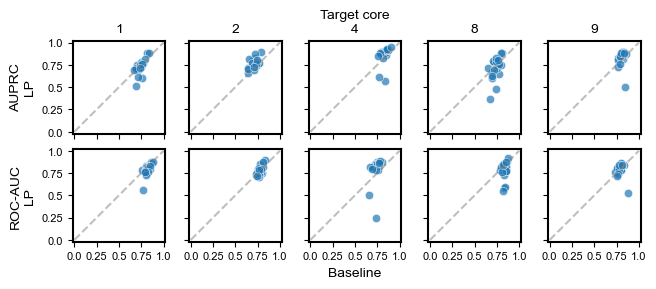

In [76]:
pd.options.mode.chained_assignment = None # silencing warning from cumcount

#  Baseline vs LP
df_to_plot = pd.DataFrame(score_dict_to_plot)
fig, ax = plt.subplots(figsize=(6.5, 5), ncols=5, nrows=2, layout="compressed", sharey=True, sharex=True)
for i, t in enumerate(target_cores):
    sub_df = df_to_plot[(df_to_plot["Target core"]==t) & (df_to_plot["Model"].isin(["Baseline", "LP"]))]
    sub_df["pair_id"] = sub_df.groupby("Model").cumcount()
        
    sub_df_wide1 = sub_df.pivot(index="pair_id", columns="Model", values="AUPRC").reset_index()
    sns.scatterplot(data=sub_df_wide1, x="Baseline", y="LP", ax=ax[0, i], alpha=0.7)
    sub_df_wide2 = sub_df.pivot(index="pair_id", columns="Model", values="ROC-AUC").reset_index()
    sns.scatterplot(data=sub_df_wide2, x="Baseline", y="LP", ax=ax[1, i], alpha=0.7)

    for j in [0, 1] :
        ax[j, i].set_aspect("equal")
        for axis in ["top", "bottom", "left", "right"]:
            ax[j, i].spines[axis].set_linewidth(1.5)
        ax[j, i].set_xlim(-0.02, 1.02)
        ax[j, i].set_ylim(-0.02, 1.02)
        ax[j, i].set_xticks(np.arange(0, 1.1, 0.25))
        ax[j, i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[j, i].set_yticks(np.arange(0, 1.1, 0.25))
        if i == 0 :
            ax[j, i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
            if j == 0 :
                ax[j, i].set_ylabel("AUPRC\nLP", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            elif j == 1:
                ax[j, i].set_ylabel("ROC-AUC\nLP", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        if i == 2 :
            if j == 1:
                ax[j, i].set_xlabel("Baseline", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            if j == 0 :
                ax[j, i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        else :
            ax[j, i].set_xlabel("")
            if j == 0:
                ax[j, i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            else :
                ax[j, i].set_title(None)


        ax[j,i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    plt.savefig("../figures/eval_second/FigureS28_Baseline_vs_LP_pairwise_comparison.svg", format="svg", dpi=300,  bbox_inches="tight")

In [77]:
from matplotlib.patches import Patch

def plot_model_score_differences(
    score_dict_to_plot,
    score="AUPRC",
    model1="Baseline",
    model2="LP",
    ymin=None,
    ymax=None,
    legend_loc="upper right",
    figsize=None,
    sharey=True,
    annotate_counts=True,
    filename=None
):
    """
    Plot sorted score differences between two models as barplots.

    Difference is computed as:

        model2_score - model1_score

    Therefore:
        negative values favor model1
        positive values favor model2

    Bars are sorted so that the left side favors model1.

    Parameters
    ----------
    score_dict_to_plot : dict
        Dictionary with keys:
            "AUPRC", "ROC-AUC", "Model", "Target core"

    score : str
        Either "AUPRC" or "ROC-AUC".

    model1 : str
        First model name. Negative differences favor this model.

    model2 : str
        Second model name. Positive differences favor this model.

    ymin : float or None
        Manual lower y-limit. If None, matplotlib chooses automatically.

    ymax : float or None
        Manual upper y-limit. If None, matplotlib chooses automatically.

    legend_loc : str
        Legend location inside the rightmost subplot.
        Example: "upper right", "lower right", "best", etc.

    figsize : tuple or None
        Figure size. If None, determined automatically.

    sharey : bool
        Whether subplots should share y-axis.

    annotate_counts : bool
        Whether to annotate number of bars favoring each model.

    Returns
    -------
    fig, axes, wide_df
        Matplotlib figure, axes, and dataframe used for plotting.
    """
    title_fontsize = 10
    ylabel_fontsize = 10
    annotation_fontsize = 8
    legend_fontsize = 8
    tick_fontsize = 8
    if score not in ["AUPRC", "ROC-AUC"]:
        raise ValueError('score must be either "AUPRC" or "ROC-AUC".')

    allowed_models = ["RFC", "Baseline", "LP", "LP (Rmap)"]
    if model1 not in allowed_models:
        raise ValueError(f"model1 must be one of {allowed_models}.")
    if model2 not in allowed_models:
        raise ValueError(f"model2 must be one of {allowed_models}.")
    if model1 == model2:
        raise ValueError("model1 and model2 must be different.")

    colors = sns.color_palette("colorblind", 8)

    colordict = {
        "LP": colors[1],
        "LP (Rmap)": colors[1],
        "RFC": colors[0],
        "Baseline": colors[-1],
    }

    df = pd.DataFrame(score_dict_to_plot).copy()

    df = df[df["Model"].isin([model1, model2])].copy()

    # This assumes model scores are paired by order within each Target core.
    df["pair_id"] = df.groupby(["Target core", "Model"]).cumcount()

    wide_df = df.pivot(
        index=["Target core", "pair_id"],
        columns="Model",
        values=score
    ).reset_index()

    wide_df = wide_df.dropna(subset=[model1, model2]).copy()

    wide_df["Difference"] = wide_df[model2] - wide_df[model1]

    wide_df["Favored model"] = np.where(
        wide_df["Difference"] < 0,
        model1,
        np.where(wide_df["Difference"] > 0, model2, "Tie")
    )

    target_cores = sorted(wide_df["Target core"].unique())
    n_targets = len(target_cores)

    if figsize is None:
        figsize = (2.1 * n_targets, 3.2)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_targets,
        figsize=figsize,
        sharey=sharey,
        layout="compressed"
    )

    if n_targets == 1:
        axes = np.array([axes])

    middle_idx = n_targets // 2

    for i, (ax, target_core) in enumerate(zip(axes, target_cores)):
        sub = wide_df[wide_df["Target core"] == target_core].copy()

        # Sort so that negative values, which favor model1, are on the left.
        sub = sub.sort_values("Difference", ascending=True).reset_index(drop=True)
        sub["bar_id"] = np.arange(len(sub))

        bar_colors = []
        for favored in sub["Favored model"]:
            if favored == "Tie":
                bar_colors.append("lightgray")
            else:
                bar_colors.append(colordict.get(favored, "lightgray"))

        ax.bar(
            sub["bar_id"],
            sub["Difference"],
            color=bar_colors,
            edgecolor="black",
            linewidth=0.4
        )

        ax.axhline(
            0,
            color="black",
            linewidth=1.0,
            linestyle="-"
        )

        # Manual ylim if requested
        if ymin is not None or ymax is not None:
            current_ymin, current_ymax = ax.get_ylim()
            ax.set_ylim(
                ymin if ymin is not None else current_ymin,
                ymax if ymax is not None else current_ymax
            )

        # Titles:
        # all plots just show core number except middle one
        core_label = target_core + 1

        if i == middle_idx:
            ax.set_title(
                f"Target core\n{core_label}",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )
        else:
            ax.set_title(
                f"{core_label}",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )

        ax.set_xlabel("")
        ax.set_xticks([])

        if i == 0:
            ax.set_ylabel(
                f"{score} difference\n{model2} - {model1}",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )
        else:
            ax.set_ylabel("")

        # Thicken all subplot boundaries
        for axis in ["top", "bottom", "left", "right"]:
            ax.spines[axis].set_linewidth(1.5)

        ax.tick_params(
            axis="y",
            labelsize=8,
            width=1.2
        )

        # Annotate number of bars favoring each model
        if annotate_counts:
            n_model1 = np.sum(sub["Difference"] < 0)
            n_model2 = np.sum(sub["Difference"] > 0)
            n_ties = np.sum(sub["Difference"] == 0)

            annotation_text = (
                f"{model1}: {n_model1}\n"
                f"{model2}: {n_model2}"
            )

            if n_ties > 0:
                annotation_text += f"\nTie: {n_ties}"

            ax.text(
                0.03,
                0.97,
                annotation_text,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                fontfamily="Arial",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=2
                )
            )

    # Legend inside the rightmost plot
    legend_handles = [
    Patch(
        facecolor=colordict[model1],
        edgecolor="black",
        label=model1
    ),
    Patch(
        facecolor=colordict[model2],
        edgecolor="black",
        label=model2
    ),
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Tie"
    )
]

    axes[-1].legend(
        handles=legend_handles,
        title="Favors",
        loc=legend_loc,
        frameon=False,
        fontsize=8,
        title_fontsize=8
    )

    if filename is not None :
        plt.savefig(f"../figures/eval_second/{filename}.svg", format="svg", dpi=300,  bbox_inches="tight")

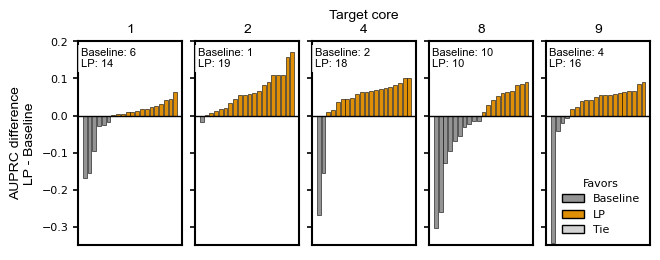

In [78]:
plot_model_score_differences(
    score_dict_to_plot,
    score="AUPRC",
    model1="Baseline",
    model2="LP",
    ymin=-0.35,
    ymax=0.2,
    legend_loc="lower right",
    figsize=(6.5, 2.5),
    sharey=True,
    annotate_counts=True,
    filename="FigureS29_Baseline_vs_LP_AUPRC_differences"
)

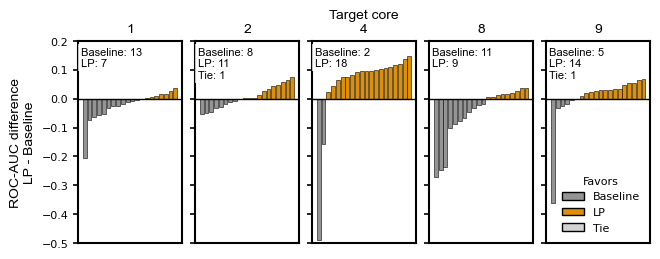

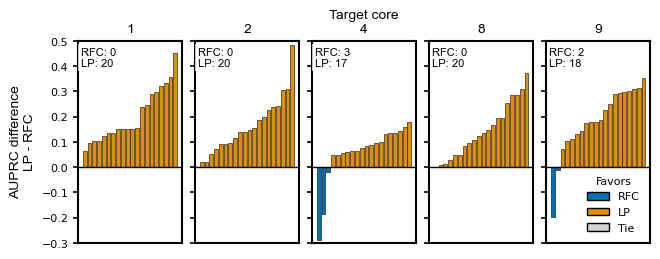

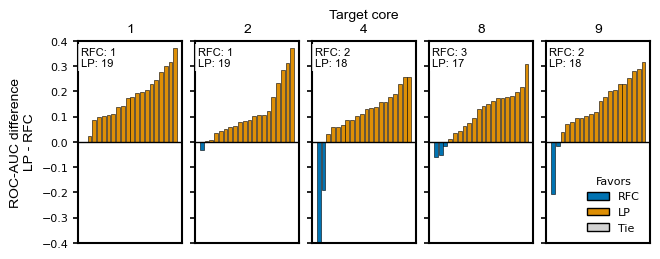

In [79]:
plot_model_score_differences(
    score_dict_to_plot,
    score="ROC-AUC",
    model1="Baseline",
    model2="LP",
    ymin=-0.5,
    ymax=0.2,
    legend_loc="lower right",
    figsize=(6.5, 2.5),
    sharey=True,
    annotate_counts=True,
    filename="FigureS30A_Baseline_vs_LP_ROC-AUC_differences"
)
plot_model_score_differences(
    score_dict_to_plot,
    score="AUPRC",
    model1="RFC",
    model2="LP",
    ymin=-0.3,
    ymax=0.5,
    legend_loc="lower right",
    figsize=(6.5, 2.5),
    sharey=True,
    annotate_counts=True,
    filename="FigureS30B_RFC_vs_LP_AUPRC_differences"
)
plot_model_score_differences(
    score_dict_to_plot,
    score="ROC-AUC",
    model1="RFC",
    model2="LP",
    ymin=-0.4,
    ymax=0.4,
    legend_loc="lower right",
    figsize=(6.5, 2.5),
    sharey=True,
    annotate_counts=True,
    filename="FigureS30C_RFC_vs_LP_ROC-AUC_differences"
)

# Top-k hits comparison

In [ ]:
def plot_topk_hits_by_target_core(
    topk_hit_dict_to_plot,
    k_col="k",
    hits_col="Top-k hits",
    model_col="Model",
    target_col="Target core",
    model_order=None,
    ymin=None,
    ymax=None,
    legend_loc="lower right",
    figsize=None,
    errorbar="sd",
    marker="o",
    xticks=None,
    xticklabels=None,
    yticks=None,
    yticklabels=None,
    filename=None,
):
    """
    Plot top-k hits versus k for each target core.

    Parameters
    ----------
    topk_hit_dict_to_plot : dict
        Dictionary containing top-k hit results.
        Expected columns by default:
            "k", "Top-k hits", "Model", "Target core"

    xticks, yticks : list, array, or None
        Tick locations for x- and y-axes.

    xticklabels, yticklabels : list, array, or None
        Tick labels for x- and y-axes.
        If None, matplotlib uses the tick values as labels.
    """

    df = pd.DataFrame(topk_hit_dict_to_plot).copy()

    required_cols = [k_col, hits_col, model_col, target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    colors = sns.color_palette("colorblind", 8)

    colordict = {
        "LP": colors[1],
        "LP (Rmap)": colors[1],
        "RFC": colors[0],
        "Baseline": colors[-1],
    }

    if model_order is None:
        model_order = [
            m for m in ["Baseline", "LP", "LP (Rmap)", "RFC"]
            if m in df[model_col].unique()
        ]

        extra_models = [
            m for m in sorted(df[model_col].unique())
            if m not in model_order
        ]

        model_order = model_order + extra_models

    target_cores = sorted(df[target_col].unique())
    n_targets = len(target_cores)

    if figsize is None:
        figsize = (2.1 * n_targets, 3.2)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_targets,
        figsize=figsize,
        sharey=True,
        layout="compressed"
    )

    if n_targets == 1:
        axes = np.array([axes])

    middle_idx = n_targets // 2

    for i, (ax, target_core) in enumerate(zip(axes, target_cores)):
        sub = df[df[target_col] == target_core].copy()

        try:
            sns.lineplot(
                data=sub,
                x=k_col,
                y=hits_col,
                hue=model_col,
                hue_order=model_order,
                palette=colordict,
                marker=marker,
                markers=True,
                dashes=False,
                estimator="mean",
                errorbar=errorbar,
                err_style="band",
                linewidth=1.5,
                markersize=5,
                ax=ax,
                legend=(i == n_targets - 1),
            )
        except TypeError:
            ci = 95 if errorbar in ["ci", ("ci", 95)] else "sd"

            sns.lineplot(
                data=sub,
                x=k_col,
                y=hits_col,
                hue=model_col,
                hue_order=model_order,
                palette=colordict,
                marker=marker,
                markers=True,
                dashes=False,
                estimator="mean",
                ci=ci,
                linewidth=1.5,
                markersize=5,
                ax=ax,
                legend=(i == n_targets - 1),
            )

        core_label = target_core + 1

        if i == middle_idx:
            ax.set_title(
                f"Target core\n{core_label}",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )
        else:
            ax.set_title(
                f"{core_label}",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )

        if i == middle_idx:
            ax.set_xlabel(
                "k",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )
        else:
            ax.set_xlabel("")

        if i == 0:
            ax.set_ylabel(
                "Top-k hits",
                fontdict={"fontsize": 10, "fontfamily": "Arial"}
            )
        else:
            ax.set_ylabel("")

        # Manual ylim if requested
        if ymin is not None or ymax is not None:
            current_ymin, current_ymax = ax.get_ylim()
            ax.set_ylim(
                ymin if ymin is not None else current_ymin,
                ymax if ymax is not None else current_ymax
            )

        # -----------------------------
        # Custom ticks and tick labels
        # -----------------------------
        if xticks is not None:
            ax.set_xticks(xticks)

        if xticklabels is not None:
            ax.set_xticklabels(
                xticklabels,
                fontsize=8,
                fontfamily="Arial"
            )

        if yticks is not None:
            ax.set_yticks(yticks)

        if yticklabels is not None:
            ax.set_yticklabels(
                yticklabels,
                fontsize=8,
                fontfamily="Arial"
            )

        # If tick labels are not explicitly provided, still control fontsize
        ax.tick_params(
            axis="both",
            labelsize=8,
            width=1.2
        )

        # Thicken subplot boundaries
        for axis in ["top", "bottom", "left", "right"]:
            ax.spines[axis].set_linewidth(1.5)

        # Legend only in the rightmost plot
        if i == n_targets - 1:
            legend = ax.get_legend()

            if legend is not None:
                ax.legend(
                    loc=legend_loc,
                    frameon=False,
                    fontsize=8,
                    title="Model",
                    title_fontsize=8
                )
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
    if filename is not None :
        plt.savefig(f"../figures/eval_second/{filename}.svg", format="svg", dpi=300,  bbox_inches="tight")

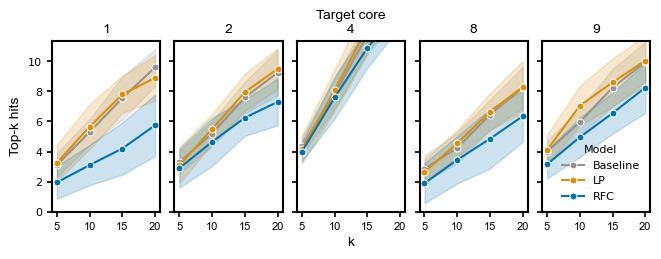

In [83]:
plot_topk_hits_by_target_core(
    topk_hit_dict_to_plot,
    model_order=["Baseline", "LP", "RFC"],
    ymin=0,
    legend_loc="lower right",
    errorbar="sd",
    figsize=(6.5, 2.5),
    hits_col="Top-k hits (hard)",
    xticks=[5, 10, 15, 20],
    xticklabels=[5, 10, 15, 20],
    # yticks=[5, 10, 15, 20],
    # yticklabels=[5, 10, 15, 20],
    filename="FigureS35A_Topk_hits_difficult"
)

[11 13 14 12]
[13 11 12 14 16]
[]
[11 12  9  8 13]
[13 18 16 12 14 17]


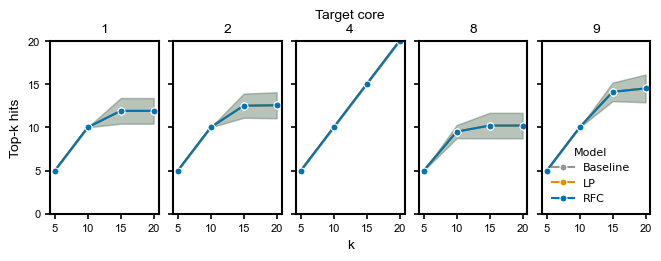

In [85]:
# All of the target cores have more than 15 hits.
# Cores 0, 1 and 7 (1, 2 and 8 in text) have less than 20 hits when k=20.
df = pd.DataFrame(topk_hit_dict_to_plot)
for t in target_cores:
    print(df[(df["Total hits (hard)"] % 5 != 0) & (df["Target core"]==t)]["Total hits (hard)"].unique())



plot_topk_hits_by_target_core(
    topk_hit_dict_to_plot,
    model_order=["Baseline", "LP", "RFC"],
    ymin=0,
    legend_loc=None,
    errorbar="sd",
    figsize=(6.5, 2.5),
    hits_col="Total hits (hard)",
    xticks=[5, 10, 15, 20],
    xticklabels=[5, 10, 15, 20],
    yticks=[0, 5, 10, 15, 20],
    yticklabels=[0, 5, 10, 15, 20],
    # filename="FigureS35B_Topk_hits_all"
)

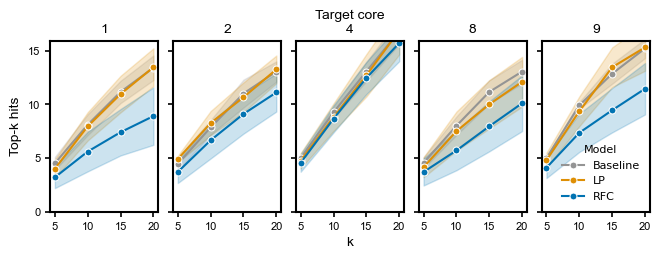

In [86]:
plot_topk_hits_by_target_core(
    topk_hit_dict_to_plot,
    model_order=["Baseline", "LP", "RFC"],
    ymin=0,
    legend_loc="lower right",
    errorbar="sd",
    figsize=(6.5, 2.5),
    hits_col="Top-k hits",
    xticks=[5, 10, 15, 20],
    xticklabels=[5, 10, 15, 20],
    yticks=[0, 5, 10, 15],
    yticklabels=[0, 5, 10, 15],
    filename="FigureS35B_Topk_hits_all"
)

[19 20 18]
[20 19 18 17]
[20]
[20 19 18 17 16]
[20]


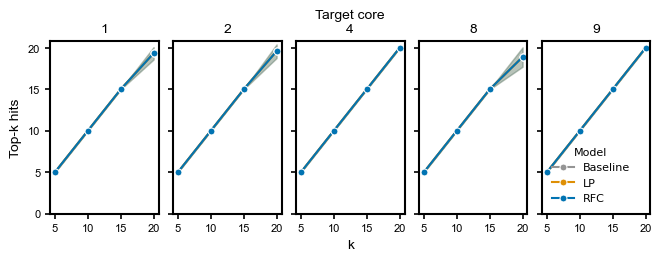

In [10]:
# All of the target cores have more than 15 hits.
# Cores 0, 1 and 7 (1, 2 and 8 in text) have less than 20 hits when k=20.
df = pd.DataFrame(topk_hit_dict_to_plot)

for t in target_cores:
    print(df[(df["k"] == 20) & (df["Target core"]==t)]["Total hits"].unique())
    # print(df[(df["Total hits"] % 5 != 0) & (df["Target core"]==t)]["Total hits"].unique())

# Total number of available hits
plot_topk_hits_by_target_core(
    topk_hit_dict_to_plot,
    model_order=["Baseline", "LP", "RFC"],
    ymin=0,
    legend_loc=None,
    errorbar="sd",
    figsize=(6.5, 2.5),
    hits_col="Total hits",
    xticks=[5, 10, 15, 20],
    xticklabels=[5, 10, 15, 20],
    yticks=[0, 5, 10, 15, 20],
    yticklabels=[0, 5, 10, 15, 20],
    # filename="FigureSX_Topk_hits_all"
)

In [11]:
# Calculating precision and recall for values to put in the abstract (LP vs RFC).
df20 = deepcopy(df[df["k"]==20])
df20["Precision@20"] = df20["Top-k hits"] / 20
df20["Recall@20"] = df20["Top-k hits"] / df20["Total hits"]

df20.groupby(["Target core", "Model"])[["Precision@20", "Recall@20"]].mean().reset_index()

,Target core,Model,Precision@20,Recall@20
0,0,Baseline,0.6700,0.692412
1,0,LP,0.6725,0.694751
2,0,RFC,0.4450,0.461871
3,1,Baseline,0.6525,0.665718
4,1,LP,0.6625,0.677173
5,1,RFC,0.5550,0.566649
6,3,Baseline,0.8400,0.840000
7,3,LP,0.8425,0.842500
8,3,RFC,0.7850,0.785000
9,7,Baseline,0.6525,0.691065


# Figure 6D

In [57]:
# Finding representative examples where baseline fails but LP succeeds.
baseline_results = joblib.load(f"../saved_results/suzuki/8/rmap_cv_6_baseline.joblib")
lp_results = joblib.load(f"../saved_results/suzuki/8/rmap_cv_6_rmap_cv.joblib")

appeared_BBs = {}
actual_ranks = {
    17:[],
}
for a, (target, train_bb_inds, remaining_inds, baseline_proba, lp_proba) in\
      enumerate(zip(baseline_results["target"], baseline_results["train_bb_inds"], baseline_results["remaining_inds"], baseline_results["proba"], lp_results["proba"])):
    print(f"=== Trial {a+1} ===")
    baseline_proba_sorted_inds = np.argsort(baseline_proba)[::-1]
    actual = [target[x] for x in baseline_proba_sorted_inds]
    rank_in_lp_proba = []
    sorted_train_bb_inds = [train_bb_inds[remaining_inds[x]] for x in baseline_proba_sorted_inds]
    for ind in baseline_proba_sorted_inds:
        indiv_lp_proba = lp_proba[ind]
        rank = np.sum(lp_proba > indiv_lp_proba)
        rank_in_lp_proba.append(rank)
    for i, x in enumerate(actual):
        train_bb_idx = sorted_train_bb_inds[i]
        if x == 0 and i < 20 and rank_in_lp_proba[i] > i:
            print(i, rank_in_lp_proba[i], train_bb_idx) # rank in baseline, rank in LP, train BB index
            if train_bb_idx not in appeared_BBs:
                appeared_BBs[train_bb_idx] = [rank_in_lp_proba[i] - i]
            else :
                appeared_BBs[train_bb_idx].append(rank_in_lp_proba[i] -i)
        if train_bb_idx == 17: # manual inspection
            actual_ranks[train_bb_idx].append((i, rank_in_lp_proba[i]))
            
    print()

=== Trial 1 ===
11 20 37
12 23 34
13 20 41
15 17 17
17 22 40

=== Trial 2 ===
13 20 40
16 21 34
17 18 37

=== Trial 3 ===
11 19 41
15 22 40
16 20 34

=== Trial 4 ===
10 15 37
15 18 34
16 29 0

=== Trial 5 ===
9 15 40
12 14 17
15 19 34
16 36 0

=== Trial 6 ===
11 22 34
12 36 17
14 24 41
16 24 37

=== Trial 7 ===
13 21 41
15 26 34
16 23 40
19 21 37

=== Trial 8 ===
12 15 34
14 22 40
16 19 60

=== Trial 9 ===
11 23 40
15 22 34
16 19 17
17 27 0
18 21 41

=== Trial 10 ===
11 21 41
14 21 37
15 25 17

=== Trial 11 ===
11 24 17
16 23 0
18 25 60

=== Trial 12 ===
14 16 34
15 21 37
17 28 0
18 23 60

=== Trial 13 ===
13 17 40
14 18 41

=== Trial 14 ===
9 17 41
12 16 17
14 17 37
15 19 34
16 28 0

=== Trial 15 ===
11 15 41
12 18 34
13 26 60

=== Trial 16 ===
10 17 17
11 18 40
16 21 34
17 19 37
18 30 0

=== Trial 17 ===
10 22 40
12 17 17
15 20 37
16 18 34
17 28 0

=== Trial 18 ===
10 35 17
12 28 37
13 31 40
14 28 41
15 20 0

=== Trial 19 ===
14 19 40
15 28 17
17 21 37
18 23 34
19 24 0

=== Trial 20 

In [58]:
# BB index, mean difference in ranking, number of appearances baseline ranks it higher than LP
for k , v in appeared_BBs.items():
    if k == 17 :
        print()
    print(k, round(np.mean(np.array(v)), 2), len(v))
    if k == 17 : # Added after recognizing big difference in ranking between baseline and lp
        print("Differences in ranks:", v)
        lp_better_count = 0 
        both_fail_count = 0
        baseline_better_count = 0
        both_success_count = 0
        for (baseline_rank, lp_rank) in actual_ranks[k]:
            if baseline_rank < 20 and lp_rank >= 20 : # The "rank" here starts from 0
                lp_better_count += 1
            elif baseline_rank < 20 and lp_rank < 20 :
                both_fail_count += 1
            elif baseline_rank >= 20 and lp_rank < 20 :
                baseline_better_count += 1
            else :
                both_success_count += 1
        print(both_success_count, lp_better_count, baseline_better_count, both_fail_count)
        print()

37 5.46 13
34 5.75 16
41 7.55 11

17 10.33 12
Differences in ranks: [2, 2, 24, 3, 10, 13, 4, 7, 5, 25, 13, 16]
0 6 0 10

40 8.17 12
0 10.6 10
60 7.0 4


In [35]:
dataset=SuzukiDataset(from_notebook=True)
reaction_data = dataset.df
core_smiles = dataset.core_smiles[8]
BB_smiles = dataset.bb_smiles[25]
reaction_data[(reaction_data["reactant_1&smiles"]==core_smiles) & (reaction_data["reactant_2&smiles"]==BB_smiles)]

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
577,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,CC1(C)OB(c2ccc3c(c2)CC(=O)N3)OC1(C)C,417718104,0.0,013


In [67]:
# Finding representative examples where baseline fails but LP succeeds.
appeared_BBs = {}
actual_ranks = {
    45:[],
    52:[],
}
for a, (target, train_bb_inds, remaining_inds, baseline_proba, lp_proba) in\
      enumerate(zip(baseline_results["target"], baseline_results["train_bb_inds"], baseline_results["remaining_inds"], baseline_results["proba"], lp_results["proba"])):
    print(f"=== Trial {a+1} ===")
    baseline_proba_sorted_inds = np.argsort(baseline_proba) # Searching for dis-prioritized
    actual = [target[x] for x in baseline_proba_sorted_inds]
    rank_in_lp_proba = []
    sorted_train_bb_inds = [train_bb_inds[remaining_inds[x]] for x in baseline_proba_sorted_inds]
    for ind in baseline_proba_sorted_inds:
        indiv_lp_proba = lp_proba[ind]
        rank = np.sum(lp_proba > indiv_lp_proba)
        rank_in_lp_proba.append(rank)
    for i, x in enumerate(actual):
        train_bb_idx = sorted_train_bb_inds[i]
        baseline_rank = len(baseline_proba_sorted_inds) - i
        # Look for BBs where yield-class is 1 but baseline ranks it outside 20
        if x == 1 and baseline_rank > 20 and rank_in_lp_proba[i] < baseline_rank:
            if rank_in_lp_proba[i] < 20 :
                print(baseline_rank, rank_in_lp_proba[i], train_bb_idx) # rank in baseline, rank in LP, train BB index
            if train_bb_idx not in appeared_BBs:
                appeared_BBs[train_bb_idx] = [baseline_rank - rank_in_lp_proba[i]]
            else :
                appeared_BBs[train_bb_idx].append(baseline_rank - rank_in_lp_proba[i])
        if train_bb_idx in [45,52]: # manual inspection
            actual_ranks[train_bb_idx].append((baseline_rank, rank_in_lp_proba[i]))
            
    print()

=== Trial 1 ===
28 12 45
23 14 7
21 10 52

=== Trial 2 ===
27 9 50
23 15 52
22 19 46
21 16 53

=== Trial 3 ===
26 9 31
24 15 7
23 12 45

=== Trial 4 ===
23 13 31
22 12 53
21 11 52

=== Trial 5 ===
27 13 45
23 16 7
21 11 31

=== Trial 6 ===
36 14 18
28 6 9
27 9 7

=== Trial 7 ===
33 9 6
29 18 45
22 14 31

=== Trial 8 ===
46 16 48
28 9 31

=== Trial 9 ===
27 14 45
26 10 31
22 16 7

=== Trial 10 ===
28 17 27
25 10 7

=== Trial 11 ===
27 15 45

=== Trial 12 ===
28 18 7
27 4 50
26 13 45

=== Trial 13 ===
26 14 45

=== Trial 14 ===
27 11 45
21 13 7

=== Trial 15 ===
26 14 45
24 9 31

=== Trial 16 ===
25 13 45
24 8 31
22 12 53
21 10 52

=== Trial 17 ===
27 9 45
26 8 50
25 15 7
24 14 31

=== Trial 18 ===
28 4 9
26 11 7
25 18 50

=== Trial 19 ===
31 14 45
30 16 31
26 10 7
23 15 53
22 12 52

=== Trial 20 ===
29 15 45
25 9 7
21 13 52



In [69]:
# BB index, mean difference in ranking, number of appearances LP ranks it higher than baseline
for k , v in appeared_BBs.items():
    if k in [45, 52]:
        print(f"===={k}====")
    # if k == 17 :
    #     print()
    # print(k, round(np.mean(np.array(v)), 2), len(v))
    # if k == 17 : # Added after recognizing big difference in ranking between baseline and lp
        print("Differences in ranks:", v)
        lp_better_count = 0 
        both_fail_count = 0
        baseline_better_count = 0
        both_success_count = 0
        for (baseline_rank, lp_rank) in actual_ranks[k]:
            if baseline_rank >= 20 and lp_rank < 20 :
                lp_better_count += 1
            elif baseline_rank >= 20 and lp_rank >= 20 :
                both_fail_count += 1
            elif baseline_rank < 20 and lp_rank >= 20 :
                baseline_better_count += 1
            else :
                both_success_count += 1
        print(both_success_count, lp_better_count, baseline_better_count, both_fail_count)
        print()

====45====
Differences in ranks: [16, 3, 11, 14, 11, 1, 13, 12, 13, 12, 16, 12, 12, 18, 17, 14]
1 14 0 3

====52====
Differences in ranks: [11, 8, 10, 11, 10, 8]
5 9 0 0



In [70]:
BB_smiles = dataset.bb_smiles[45]
reaction_data[(reaction_data["reactant_1&smiles"]==core_smiles) & (reaction_data["reactant_2&smiles"]==BB_smiles)]

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
597,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,N#Cc1ccc(B(O)O)cc1,417704778,88.841732,"[012, 012]"


## Overall comparison of LP and Baseline's predictions

In [6]:
def get_two_results(target_core_ind):
    """ Retrieves the predicted probabilities for every BB in the 20 bootstrap trials. """
    dir = f"../saved_results/suzuki/{target_core_ind}"
    rmap_results = joblib.load(os.path.join(dir, "rmap_cv_6_rmap_cv.joblib"))
    baseline_results = joblib.load(os.path.join(dir, "rmap_cv_6_baseline.joblib"))
    rfcc_results = joblib.load(os.path.join(dir, "rmap_cv_6_rfc_combined.joblib"))

    all_proba = -1 * np.ones((69, 20, 4)) # 69 BBs, 20 bootstrap trials, 3 models
    for z, result in enumerate([rmap_results, baseline_results, rfcc_results]): 
        for y, t_inds, proba_vals, remaining in zip(
            result["bootstrap_id"], 
            result["train_bb_inds"], 
            result["proba"], 
            result["remaining_inds"]
        ):
            all_proba[[t_inds[x] for x in remaining], y, z] = proba_vals.flatten()
    all_proba[all_proba < 0] = np.nan
    print(all_proba.shape)
    average_proba = np.nanmean(all_proba, axis= 1)

    rmap = ReactivityMap(
        source_core_inds=None,
        target_core_ind=target_core_ind,
        test_bb_inds=[],
        dataset=SuzukiDataset(from_notebook=True)
    )
    actual = rmap.target_reactivity_array

    return average_proba, actual

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


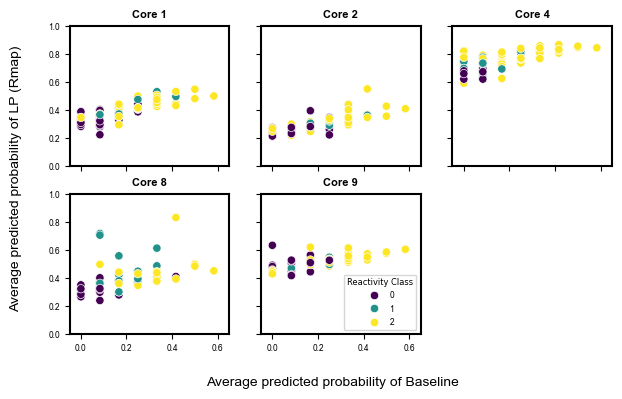

In [95]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(7, 4), sharey=True, sharex=True)

for j, i in enumerate([0, 1, 3, 7, 8]):
    target0_avg_proba, target0_reactivity = get_two_results(i)

    # fig, ax = plt.subplots(figsize=(3,3))
    rmap_vs_baseline_dict = {
        "LP (Rmap)": target0_avg_proba[:, 0],
        "Baseline": target0_avg_proba[:, 1],
        "Actual": target0_reactivity
    }   
    rmap_vs_baseline_df = pd.DataFrame(rmap_vs_baseline_dict).dropna()
    sns.scatterplot(data=rmap_vs_baseline_df, y="LP (Rmap)", x="Baseline", hue="Actual", palette="viridis", ax=ax[j//3, j%3])
    for axis in ["top", "bottom", "left", "right"]:
        ax[j//3, j%3].spines[axis].set_linewidth(1.5)

    ax[j//3, j%3].set_title(f"Core {i+1}", fontsize=8, fontfamily="arial", fontweight="bold")
    ax[j//3, j%3].set_xlim(-0.05, 0.65)
    ax[j//3, j%3].set_xlabel("", fontsize=8, fontfamily="arial")
    ax[j//3, j%3].set_ylabel("", fontsize=8, fontfamily="arial")
    ax[j//3, j%3].set_yticks([round(x, 1) for x in np.arange(0, 1.1, 0.2)])
    ax[j//3, j%3].set_yticklabels([round(x, 1) for x in np.arange(0, 1.1, 0.2)], fontsize=6, fontfamily="arial")
    ax[j//3, j%3].set_xticks([0, 0.2, 0.4, 0.6])
    ax[j//3, j%3].set_xticklabels(["0.0"]+[round(x, 1) for x in np.arange(0.2, 0.65, 0.2)], fontsize=6, fontfamily="arial")
    if j == 4 :
        ax[j//3, j%3].legend(title="Reactivity Class", prop=fm.FontProperties(family="Arial", size=6), title_fontsize=6, loc="lower right")
    else :
        ax[j//3, j%3].get_legend().remove()
    for axis in ["top", "bottom", "left", "right"]:
        ax[j//3, j%3].spines[axis].set_linewidth(1.5)
    
for loc in ["top", "right", "bottom", "left"]:
    ax[1, 2].spines[loc].set_visible(False)
    ax[1, 2].xaxis.set_visible(False)
    ax[1, 2].yaxis.set_visible(False)
fig.text(0.04, 0.5, "Average predicted probability of LP (Rmap)", fontsize=10, fontfamily="arial", rotation="vertical", va="center")
fig.text(0.5, -0.02, "Average predicted probability of Baseline", fontsize=10, fontfamily="arial", ha="center")
plt.savefig(f"../figures/eval_second/FigureS36.svg", dpi=300, bbox_inches="tight", format="svg")

## Looking at specific BB examples for core 8

In [98]:
target7_avg_proba, target7_reactivity = get_two_results(7)
rmap_vs_baseline_dict = {
    "LP (Rmap)": target7_avg_proba[:, 0],
    "Baseline": target7_avg_proba[:, 1],
    "Actual": target7_reactivity
}   
rmap_vs_baseline_df = pd.DataFrame(rmap_vs_baseline_dict).dropna()

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


### Example of LP successfully deprioritizing low-yielding while baseline fails

In [99]:
rmap_vs_baseline_df[(rmap_vs_baseline_df["Baseline"] > 0.4) & (rmap_vs_baseline_df["LP (Rmap)"] < 0.5)]

,LP (Rmap),Baseline,Actual
15,0.497705,0.500000,2
30,0.392803,0.416667,2
36,0.404273,0.416667,2
38,0.410427,0.416667,0
47,0.451186,0.583333,2
49,0.484661,0.500000,2
68,0.393349,0.416667,2


In [101]:
rmap_vs_baseline_df.shape

(68, 3)

In [104]:
rmap7 = ReactivityMap(
    source_core_inds=None,
    target_core_ind=7,
    test_bb_inds=[],
    dataset=SuzukiDataset(from_notebook=True)
)
rmap7.dataset.yield_array[7, 38] # The first row in the output of the cell above

19.731771552999998

In [105]:
rmap7.dataset.bb_smiles[38]

'N#Cc1cc(F)cc(B(O)O)c1'

### Example of LP successfully prioritizing high-yielding while baseline fails

In [106]:
rmap_vs_baseline_df[(rmap_vs_baseline_df["Baseline"] < 0.2) & (rmap_vs_baseline_df["LP (Rmap)"] > 0.4)]

,LP (Rmap),Baseline,Actual
2,0.717922,0.083333,1
9,0.421767,0.166667,1
10,0.497345,0.083333,2
18,0.558358,0.166667,1
34,0.441926,0.166667,2
48,0.401656,0.083333,0
66,0.706117,0.083333,1


In [107]:
rmap7.dataset.yield_array[7, 10] # The first row in the output of the cell above

41.01494829

In [108]:
rmap7.dataset.bb_smiles[10]

'COc1ccc(B(O)O)c(C)c1'

## Looking at specific BB examples for core 9

In [109]:
target9_avg_proba, target9_reactivity = get_two_results(8)
rmap_vs_baseline_dict2 = {
    "LP (Rmap)": target9_avg_proba[:, 0],
    "Baseline": target9_avg_proba[:, 1],
    "Actual": target9_reactivity
}   
rmap_vs_baseline_df2 = pd.DataFrame(rmap_vs_baseline_dict2).dropna()

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


In [110]:
rmap_vs_baseline_df2[(rmap_vs_baseline_df2["Baseline"] < 0.2) & (rmap_vs_baseline_df2["LP (Rmap)"] > 0.6) & (rmap_vs_baseline_df2["Actual"] == 2)]

,LP (Rmap),Baseline,Actual
50,0.620288,0.166667,2


In [111]:
rmap8 = ReactivityMap(
    source_core_inds=None,
    target_core_ind=8,
    test_bb_inds=[],
    dataset=SuzukiDataset(from_notebook=True)
)
rmap8.dataset.yield_array[8, 50] # The first row in the output of the cell above

44.7680244

In [112]:
rmap8.dataset.bb_smiles[50]

'COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1S(N)(=O)=O'

## Core 4

In [113]:
target4_avg_proba, target4_reactivity = get_two_results(3)
rmap_vs_baseline_dict4 = {
    "LP (Rmap)": target4_avg_proba[:, 0],
    "Baseline": target4_avg_proba[:, 1],
    "Actual": target4_reactivity
}   
rmap_vs_baseline_df4 = pd.DataFrame(rmap_vs_baseline_dict4).dropna()

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_2834/2696537073.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


In [115]:
rmap_vs_baseline_df4[(rmap_vs_baseline_df4["Baseline"] < 0.2) & (rmap_vs_baseline_df4["LP (Rmap)"] > 0.6) & (rmap_vs_baseline_df4["Actual"] == 2)]

,LP (Rmap),Baseline,Actual
0,0.762092,0.166667,2
4,0.820482,0.000000,2
7,0.774917,0.166667,2
8,0.753184,0.000000,2
9,0.742569,0.083333,2
10,0.791732,0.083333,2
11,0.707010,0.000000,2
13,0.712054,0.000000,2
17,0.730949,0.166667,2
18,0.731009,0.083333,2


In [116]:
rmap4 = ReactivityMap(
    source_core_inds=None,
    target_core_ind=4,
    test_bb_inds=[],
    dataset=SuzukiDataset(from_notebook=True)
)
rmap4.dataset.yield_array[3, 24] # The first row in the output of the cell above

58.940089890935084

In [117]:
rmap4.dataset.bb_smiles[24]

'COc1ccc(B(O)O)cn1'